<a href="https://colab.research.google.com/github/dellae09/academic-performance-clustering-kmeans-sa/blob/main/06_Pola_Nilai_dan_Keputusan_Intervensi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

1. LOAD DATASET

In [ ]:
file_path = "/content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING/19_deploy_dataset_with_cluster_sa.csv"

df = pd.read_csv(file_path)

2. FUNGSI KATEGORI PERUBAHAN

In [ ]:
def categorize_change(before, after, threshold=5):
    diff = after - before
    if diff > threshold:
        return "Naik"
    elif diff < -threshold:
        return "Turun"
    else:
        return "Stabil"

3. PEMBENTUKAN POLA

In [ ]:
df["Pre_Post"] = df.apply(lambda row: categorize_change(row["Nilai_Pretest"], row["Nilai_Posttest"]), axis=1)

df["Post_Ujian"] = df.apply(lambda row: categorize_change(row["Nilai_Posttest"], row["Nilai_Ujian"]), axis=1)

df["Kombinasi"] = df["Pre_Post"] + " → " + df["Post_Ujian"]

print("\nPreview Data dengan Pola:")
display(df.head())


Preview Data dengan Pola:


,NPM,Nama,Nilai_Pretest,Nilai_Posttest,Nilai_Ujian,Cluster,Pre_Post,Post_Ujian,Kombinasi
0,G1F021045,Ananda Naila Evril,78.12,40.62,57.14,1,Turun,Naik,Turun → Naik
1,G1F022002,Ulfa,38.89,33.33,48.00,0,Turun,Naik,Turun → Naik
2,G1F022005,Ahmad Fadhila,89.29,64.29,62.07,1,Turun,Stabil,Turun → Stabil
3,G1F022007,AHMAD DWICAHYADI,80.56,41.67,28.00,0,Turun,Turun,Turun → Turun
4,G1F022008,Meisy Dianita,88.89,88.89,84.00,1,Stabil,Stabil,Stabil → Stabil


4. FREKUENSI POLA

In [ ]:
pola_counts = df["Kombinasi"].value_counts().reset_index()
pola_counts.columns = ["Kombinasi", "Jumlah"]

print("\nFrekuensi Pola:")
display(pola_counts)


Frekuensi Pola:


,Kombinasi,Jumlah
0,Naik → Turun,34
1,Turun → Naik,33
2,Stabil → Turun,27
3,Turun → Turun,19
4,Stabil → Stabil,13
5,Naik → Stabil,9
6,Stabil → Naik,8
7,Turun → Stabil,7
8,Naik → Naik,6


5. POLA TEORITIS

In [ ]:
kemungkinan_teoritis = [
    "Naik → Naik", "Naik → Turun", "Naik → Stabil",
    "Turun → Naik", "Turun → Turun", "Turun → Stabil",
    "Stabil → Naik", "Stabil → Turun", "Stabil → Stabil"
]

df_teori = pd.DataFrame(kemungkinan_teoritis, columns=["Kombinasi_Teoritis"])

df_compare = df_teori.merge(
    pola_counts,
    left_on="Kombinasi_Teoritis",
    right_on="Kombinasi",
    how="left"
)

df_compare["Jumlah"] = df_compare["Jumlah"].fillna(0).astype(int)
df_compare = df_compare.drop(columns=["Kombinasi"])

print("\nPerbandingan Pola Teoritis vs Aktual:")
display(df_compare)


Perbandingan Pola Teoritis vs Aktual:


,Kombinasi_Teoritis,Jumlah
0,Naik → Naik,6
1,Naik → Turun,34
2,Naik → Stabil,9
3,Turun → Naik,33
4,Turun → Turun,19
5,Turun → Stabil,7
6,Stabil → Naik,8
7,Stabil → Turun,27
8,Stabil → Stabil,13


 6. ANALISIS PER CLUSTER


In [ ]:
cluster_analysis = (
    df.groupby(["Cluster", "Kombinasi"])
      .size()
      .reset_index(name="Jumlah")
)

cluster_analysis = cluster_analysis.sort_values(
    by=["Cluster", "Jumlah"],
    ascending=[True, False]
).reset_index(drop=True)

cluster_analysis["Cluster"] = cluster_analysis["Cluster"].map({
    0: "Cluster 0 (Rendah)",
    1: "Cluster 1 (Tinggi)"
})

cluster_analysis.index += 1
cluster_analysis = cluster_analysis.reset_index().rename(columns={"index": "No"})

print("\nAnalisis Pola per Cluster:")
display(cluster_analysis)


Analisis Pola per Cluster:


,No,Cluster,Kombinasi,Jumlah
0,1,Cluster 0 (Rendah),Turun → Naik,19
1,2,Cluster 0 (Rendah),Naik → Turun,10
2,3,Cluster 0 (Rendah),Stabil → Naik,6
3,4,Cluster 0 (Rendah),Naik → Naik,4
4,5,Cluster 0 (Rendah),Turun → Turun,4
5,6,Cluster 0 (Rendah),Naik → Stabil,3
6,7,Cluster 0 (Rendah),Stabil → Stabil,2
7,8,Cluster 0 (Rendah),Stabil → Turun,2
8,9,Cluster 1 (Tinggi),Stabil → Turun,25
9,10,Cluster 1 (Tinggi),Naik → Turun,24


7. DATASET BARU: CLUSTER + POLA (INDIVIDU)

In [ ]:
dataset_cluster_pola = df[[
    "NPM",
    "Cluster",
    "Pre_Post",
    "Post_Ujian",
    "Kombinasi"
]].copy()

dataset_cluster_pola["Cluster"] = dataset_cluster_pola["Cluster"].map({
    0: "Cluster 0 (Rendah)",
    1: "Cluster 1 (Tinggi)"
})

print("\nDataset Cluster dan Pola (Individu):")
display(dataset_cluster_pola.head(20))


Dataset Cluster dan Pola (Individu):


,NPM,Cluster,Pre_Post,Post_Ujian,Kombinasi
0,G1F021045,Cluster 1 (Tinggi),Turun,Naik,Turun → Naik
1,G1F022002,Cluster 0 (Rendah),Turun,Naik,Turun → Naik
2,G1F022005,Cluster 1 (Tinggi),Turun,Stabil,Turun → Stabil
3,G1F022007,Cluster 0 (Rendah),Turun,Turun,Turun → Turun
4,G1F022008,Cluster 1 (Tinggi),Stabil,Stabil,Stabil → Stabil
5,G1F022013,Cluster 1 (Tinggi),Turun,Naik,Turun → Naik
6,G1F022014,Cluster 1 (Tinggi),Naik,Turun,Naik → Turun
7,G1F022016,Cluster 1 (Tinggi),Naik,Turun,Naik → Turun
8,G1F022019,Cluster 1 (Tinggi),Stabil,Stabil,Stabil → Stabil
9,G1F022020,Cluster 1 (Tinggi),Stabil,Turun,Stabil → Turun


8. VISUALISASI

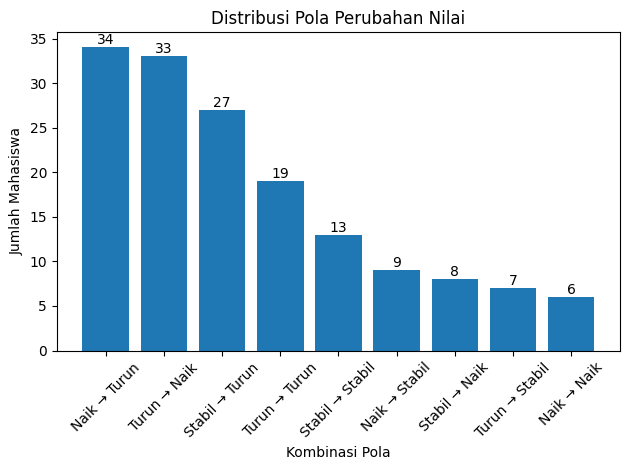


Visualisasi berhasil ditampilkan dan disimpan.


In [ ]:
output_folder = "/content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Penentuan Pola"
os.makedirs(output_folder, exist_ok=True)

pola_counts_sorted = pola_counts.sort_values(by="Jumlah", ascending=False)

plt.figure()
bars = plt.bar(pola_counts_sorted["Kombinasi"], pola_counts_sorted["Jumlah"])

plt.xticks(rotation=45)
plt.xlabel("Kombinasi Pola")
plt.ylabel("Jumlah Mahasiswa")
plt.title("Distribusi Pola Perubahan Nilai")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.tight_layout()

# tampilkan di notebook
plt.show()

# simpan gambar
visual_path = output_folder + "/Visualisasi_Distribusi_Pola.png"
plt.savefig(visual_path)
plt.close()

print("\nVisualisasi berhasil ditampilkan dan disimpan.")

9. SIMPAN SEMUA HASIL

In [ ]:
df_compare.to_csv(output_folder + "/Ringkasan_Pola_Teoritis_vs_Aktual.csv", index=False)
pola_counts.to_csv(output_folder + "/Frekuensi_Pola_Aktual.csv", index=False)
cluster_analysis.to_csv(output_folder + "/Pola_Per_Cluster.csv", index=False)
dataset_cluster_pola.to_csv(output_folder + "/Dataset_Cluster_dan_Pola.csv", index=False)

print("\nSemua hasil berhasil disimpan dalam format CSV.")


Semua hasil berhasil disimpan dalam format CSV.
